# Cross-Method Notebook

This notebook collects the cross-method comparison plots for the g-and-k and Lotka--Volterra experiments. It follows the same repo-local format as the other notebooks: edit the file paths in the setup section, render figures inline, and save the outputs to `figures/`.



In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

GK_OUTPUT = FIGURES_DIR / "gk_cross_method_comparison.pdf"
LV_OUTPUT = FIGURES_DIR / "lv_cross_method_comparison.pdf"
SUMMARY_OUTPUT = FIGURES_DIR / "cross_method_summary.pdf"

FIGSIZE = (6, 4)
SUMMARY_DPI = 150
TITLE_SIZE = 28
LABEL_SIZE = 26
TICK_SIZE = 22
LEGEND_SIZE = 20
LINE_WIDTH = 2.0
TITLE_PAD = 8

METHOD_COLORS = {
    "sgd": "#006d2c",          # deep green
    "adaptive_sgd": "#238b45", # distinct darker green
    "pgd": "#d95f02",
    "fixed_pgd": "#ff9da6",
}


BASE_PLOT_RC = {
    "axes.grid": True,
    "font.family": "DeJavu Serif",
    "font.serif": ["Times New Roman"],
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath, amsfonts, mathrsfs, amssymb}",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    "legend.frameon": False,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "lines.linewidth": LINE_WIDTH,
    "figure.figsize": FIGSIZE,
    "figure.dpi": 100,
}
LOCAL_PLOT_RC = dict(BASE_PLOT_RC)
plt.rcParams.update(BASE_PLOT_RC)


def _load_npz_dict(npz_path):
    npz_path = Path(npz_path)
    with np.load(npz_path) as data:
        return {key: data[key] for key in data.files}


def _save_figure(fig, output_path=None, **savefig_kwargs):
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, **savefig_kwargs)
    return fig


def _theta_error_histories(data, histories_key, theta_true_key="theta_true"):
    theta_true = np.asarray(data[theta_true_key], dtype=float)
    histories = np.asarray(data[histories_key], dtype=float)
    return np.linalg.norm(histories - theta_true[None, None, :], axis=-1)


def make_gk_cross_method_comparison(npz_path, output_path=None):
    data = _load_npz_dict(npz_path)
    required = [
        "theta_true",
        "baseline_theta_histories",
        "adaptive_sgd_theta_histories",
        "adaptive_theta_histories",
        "fixed_pgd_theta_histories",
        "baseline_history_steps",
        "adaptive_sgd_history_steps",
        "adaptive_history_steps",
        "fixed_pgd_history_steps",
    ]
    missing = [key for key in required if key not in data]
    if missing:
        raise KeyError("Missing keys for G-and-K cross-method comparison: " + ", ".join(missing))

    baseline_err = _theta_error_histories(data, "baseline_theta_histories")
    adaptive_sgd_err = _theta_error_histories(data, "adaptive_sgd_theta_histories")
    pgd_err = _theta_error_histories(data, "adaptive_theta_histories")
    fixed_pgd_err = _theta_error_histories(data, "fixed_pgd_theta_histories")

    baseline_steps = np.asarray(data["baseline_history_steps"], dtype=float) + 1.0
    adaptive_sgd_steps = np.asarray(data["adaptive_sgd_history_steps"], dtype=float) + 1.0
    pgd_steps = np.asarray(data["adaptive_history_steps"], dtype=float) + 1.0
    fixed_pgd_steps = np.asarray(data["fixed_pgd_history_steps"], dtype=float) + 1.0

    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(8.2, 5.0), dpi=SUMMARY_DPI)
        ax.plot(baseline_steps, np.mean(baseline_err, axis=0), color=METHOD_COLORS["sgd"], label="SGD fixed $\ell$")
        ax.plot(adaptive_sgd_steps, np.mean(adaptive_sgd_err, axis=0), color=METHOD_COLORS["adaptive_sgd"], label="SGD adaptive $\ell$")
        ax.plot(pgd_steps, np.mean(pgd_err, axis=0), color=METHOD_COLORS["pgd"], label="PGD adaptive $\ell$")
        ax.plot(fixed_pgd_steps, np.mean(fixed_pgd_err, axis=0), color=METHOD_COLORS["fixed_pgd"], label="PGD fixed $\ell$")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("")
        ax.set_title("G-and-k cross-method comparison", pad=TITLE_PAD)
        ax.legend(loc="best")
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def make_lv_cross_method_comparison(npz_path, output_path=None, max_iteration=11000):
    data = _load_npz_dict(npz_path)
    required = [
        "theta_true",
        "sgd_theta_histories",
        "adaptive_sgd_theta_histories",
        "pgd_theta_histories",
        "fixed_pgd_theta_histories",
        "sgd_history_steps",
        "adaptive_sgd_history_steps",
        "pgd_history_steps",
        "fixed_pgd_history_steps",
    ]
    missing = [key for key in required if key not in data]
    if missing:
        raise KeyError("Missing keys for LV cross-method comparison: " + ", ".join(missing))

    sgd_err = _theta_error_histories(data, "sgd_theta_histories")
    adaptive_sgd_err = _theta_error_histories(data, "adaptive_sgd_theta_histories")
    pgd_err = _theta_error_histories(data, "pgd_theta_histories")
    fixed_pgd_err = _theta_error_histories(data, "fixed_pgd_theta_histories")

    sgd_steps = np.asarray(data["sgd_history_steps"], dtype=float) + 1.0
    adaptive_sgd_steps = np.asarray(data["adaptive_sgd_history_steps"], dtype=float) + 1.0
    pgd_steps = np.asarray(data["pgd_history_steps"], dtype=float) + 1.0
    fixed_pgd_steps = np.asarray(data["fixed_pgd_history_steps"], dtype=float) + 1.0

    def truncate(steps, errors):
        mask = steps <= float(max_iteration)
        return steps[mask], errors[:, mask]

    sgd_steps, sgd_err = truncate(sgd_steps, sgd_err)
    adaptive_sgd_steps, adaptive_sgd_err = truncate(adaptive_sgd_steps, adaptive_sgd_err)
    pgd_steps, pgd_err = truncate(pgd_steps, pgd_err)
    fixed_pgd_steps, fixed_pgd_err = truncate(fixed_pgd_steps, fixed_pgd_err)

    with plt.rc_context(LOCAL_PLOT_RC):
        fig, ax = plt.subplots(figsize=(8.2, 5.0), dpi=SUMMARY_DPI)
        ax.plot(sgd_steps, np.mean(sgd_err, axis=0), color=METHOD_COLORS["sgd"], label="GD (fixed $\ell$)")
        ax.plot(adaptive_sgd_steps, np.mean(adaptive_sgd_err, axis=0), color=METHOD_COLORS["adaptive_sgd"], label="GD (adaptive $\ell$)")
        ax.plot(pgd_steps, np.mean(pgd_err, axis=0), color=METHOD_COLORS["pgd"], label="PGD (adaptive $\ell$)")
        ax.plot(fixed_pgd_steps, np.mean(fixed_pgd_err, axis=0), color=METHOD_COLORS["fixed_pgd"], label="PGD (fixed $\ell$)")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Iteration")
        ax.set_ylabel(r"$\|\theta_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$")
        ax.set_title("Lotka--Volterra cross-method comparison", pad=TITLE_PAD)
        ax.legend(loc="best")
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")


def _draw_gk_cross_method(ax, npz_path):
    data = _load_npz_dict(npz_path)
    required = [
        "theta_true",
        "baseline_theta_histories",
        "adaptive_sgd_theta_histories",
        "adaptive_theta_histories",
        "fixed_pgd_theta_histories",
        "baseline_history_steps",
        "adaptive_sgd_history_steps",
        "adaptive_history_steps",
        "fixed_pgd_history_steps",
    ]
    missing = [key for key in required if key not in data]
    if missing:
        raise KeyError("Missing keys for G-and-K cross-method comparison: " + ", ".join(missing))
    baseline_err = _theta_error_histories(data, "baseline_theta_histories")
    adaptive_sgd_err = _theta_error_histories(data, "adaptive_sgd_theta_histories")
    pgd_err = _theta_error_histories(data, "adaptive_theta_histories")
    fixed_pgd_err = _theta_error_histories(data, "fixed_pgd_theta_histories")
    baseline_steps = np.asarray(data["baseline_history_steps"], dtype=float) + 1.0
    adaptive_sgd_steps = np.asarray(data["adaptive_sgd_history_steps"], dtype=float) + 1.0
    pgd_steps = np.asarray(data["adaptive_history_steps"], dtype=float) + 1.0
    fixed_pgd_steps = np.asarray(data["fixed_pgd_history_steps"], dtype=float) + 1.0
    ax.plot(baseline_steps, np.mean(baseline_err, axis=0), color=METHOD_COLORS["sgd"], label="GD (fixed $\ell$)")
    ax.plot(adaptive_sgd_steps, np.mean(adaptive_sgd_err, axis=0), color=METHOD_COLORS["adaptive_sgd"], label="GD (adaptive $\ell$)")
    ax.plot(pgd_steps, np.mean(pgd_err, axis=0), color=METHOD_COLORS["pgd"], label="PGD (adaptive $\ell$)")
    ax.plot(fixed_pgd_steps, np.mean(fixed_pgd_err, axis=0), color=METHOD_COLORS["fixed_pgd"], label="PGD (fixed $\ell$)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    ax.set_ylabel(r"$\|\theta_{\mathrm{final}}-\theta_{\mathrm{true}}\|_2$")
    ax.set_title("G-and-K distribution", pad=TITLE_PAD)
    ax.legend(loc="best", frameon=True)


def _draw_lv_cross_method(ax, npz_path, max_iteration=11000):
    data = _load_npz_dict(npz_path)
    required = [
        "theta_true",
        "sgd_theta_histories",
        "adaptive_sgd_theta_histories",
        "pgd_theta_histories",
        "fixed_pgd_theta_histories",
        "sgd_history_steps",
        "adaptive_sgd_history_steps",
        "pgd_history_steps",
        "fixed_pgd_history_steps",
    ]
    missing = [key for key in required if key not in data]
    if missing:
        raise KeyError("Missing keys for LV cross-method comparison: " + ", ".join(missing))
    sgd_err = _theta_error_histories(data, "sgd_theta_histories")
    adaptive_sgd_err = _theta_error_histories(data, "adaptive_sgd_theta_histories")
    pgd_err = _theta_error_histories(data, "pgd_theta_histories")
    fixed_pgd_err = _theta_error_histories(data, "fixed_pgd_theta_histories")
    sgd_steps = np.asarray(data["sgd_history_steps"], dtype=float) + 1.0
    adaptive_sgd_steps = np.asarray(data["adaptive_sgd_history_steps"], dtype=float) + 1.0
    pgd_steps = np.asarray(data["pgd_history_steps"], dtype=float) + 1.0
    fixed_pgd_steps = np.asarray(data["fixed_pgd_history_steps"], dtype=float) + 1.0
    def truncate(steps, errors):
        mask = steps <= float(max_iteration)
        return steps[mask], errors[:, mask]
    sgd_steps, sgd_err = truncate(sgd_steps, sgd_err)
    adaptive_sgd_steps, adaptive_sgd_err = truncate(adaptive_sgd_steps, adaptive_sgd_err)
    pgd_steps, pgd_err = truncate(pgd_steps, pgd_err)
    fixed_pgd_steps, fixed_pgd_err = truncate(fixed_pgd_steps, fixed_pgd_err)
    ax.plot(sgd_steps, np.mean(sgd_err, axis=0), color=METHOD_COLORS["sgd"], label="GD (fixed $\ell$)")
    ax.plot(adaptive_sgd_steps, np.mean(adaptive_sgd_err, axis=0), color=METHOD_COLORS["adaptive_sgd"], label="GD (adaptive $\ell$)")
    ax.plot(pgd_steps, np.mean(pgd_err, axis=0), color=METHOD_COLORS["pgd"], label="PGD (adaptive $\ell$)")
    ax.plot(fixed_pgd_steps, np.mean(fixed_pgd_err, axis=0), color=METHOD_COLORS["fixed_pgd"], label="PGD (fixed $\ell$)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("")
    ax.set_title("Lotka--Volterra", pad=TITLE_PAD)
    ax.legend(loc="best", frameon=True)


def make_cross_method_summary(gk_compare_npz, lv_compare_npz, output_path=None, figsize=(16, 5), dpi=150, max_iteration=11000):
    with plt.rc_context(LOCAL_PLOT_RC):
        fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=dpi)
        _draw_gk_cross_method(axes[0], gk_compare_npz)
        _draw_lv_cross_method(axes[1], lv_compare_npz, max_iteration=max_iteration)
        fig.tight_layout()
        return _save_figure(fig, output_path, bbox_inches="tight")





## Local file setup

These defaults match the saved cross-method files currently in this repo.



In [2]:
gk_compare_npz = ROOT / "cross_method"/ "gnk"/ "g_n_k_fixed600_theta0_2p000_2p000_1p500_m0p300.npz"
lv_compare_npz = ROOT / "cross_method"/ "lv"/"lotka_volterra_results_pgd_vs_sgd.npz"

{
    "gk_compare_npz": gk_compare_npz,
    "lv_compare_npz": lv_compare_npz,
    "outputs": [GK_OUTPUT, LV_OUTPUT],
}




{'gk_compare_npz': PosixPath('/home/zongchen/MDF_AL/cross_method/gnk/g_n_k_fixed600_theta0_2p000_2p000_1p500_m0p300.npz'),
 'lv_compare_npz': PosixPath('/home/zongchen/MDF_AL/cross_method/lv/lotka_volterra_results_pgd_vs_sgd.npz'),
 'outputs': [PosixPath('/home/zongchen/MDF_AL/figures/gk_cross_method_comparison.pdf'),
  PosixPath('/home/zongchen/MDF_AL/figures/lv_cross_method_comparison.pdf')]}

In [3]:
available_inputs = {
    "gk_compare_npz": gk_compare_npz.exists(),
    "lv_compare_npz": lv_compare_npz.exists(),
}
available_inputs



{'gk_compare_npz': True, 'lv_compare_npz': True}

Saved figure to /home/zongchen/MDF_AL/figures/cross_method_summary.pdf


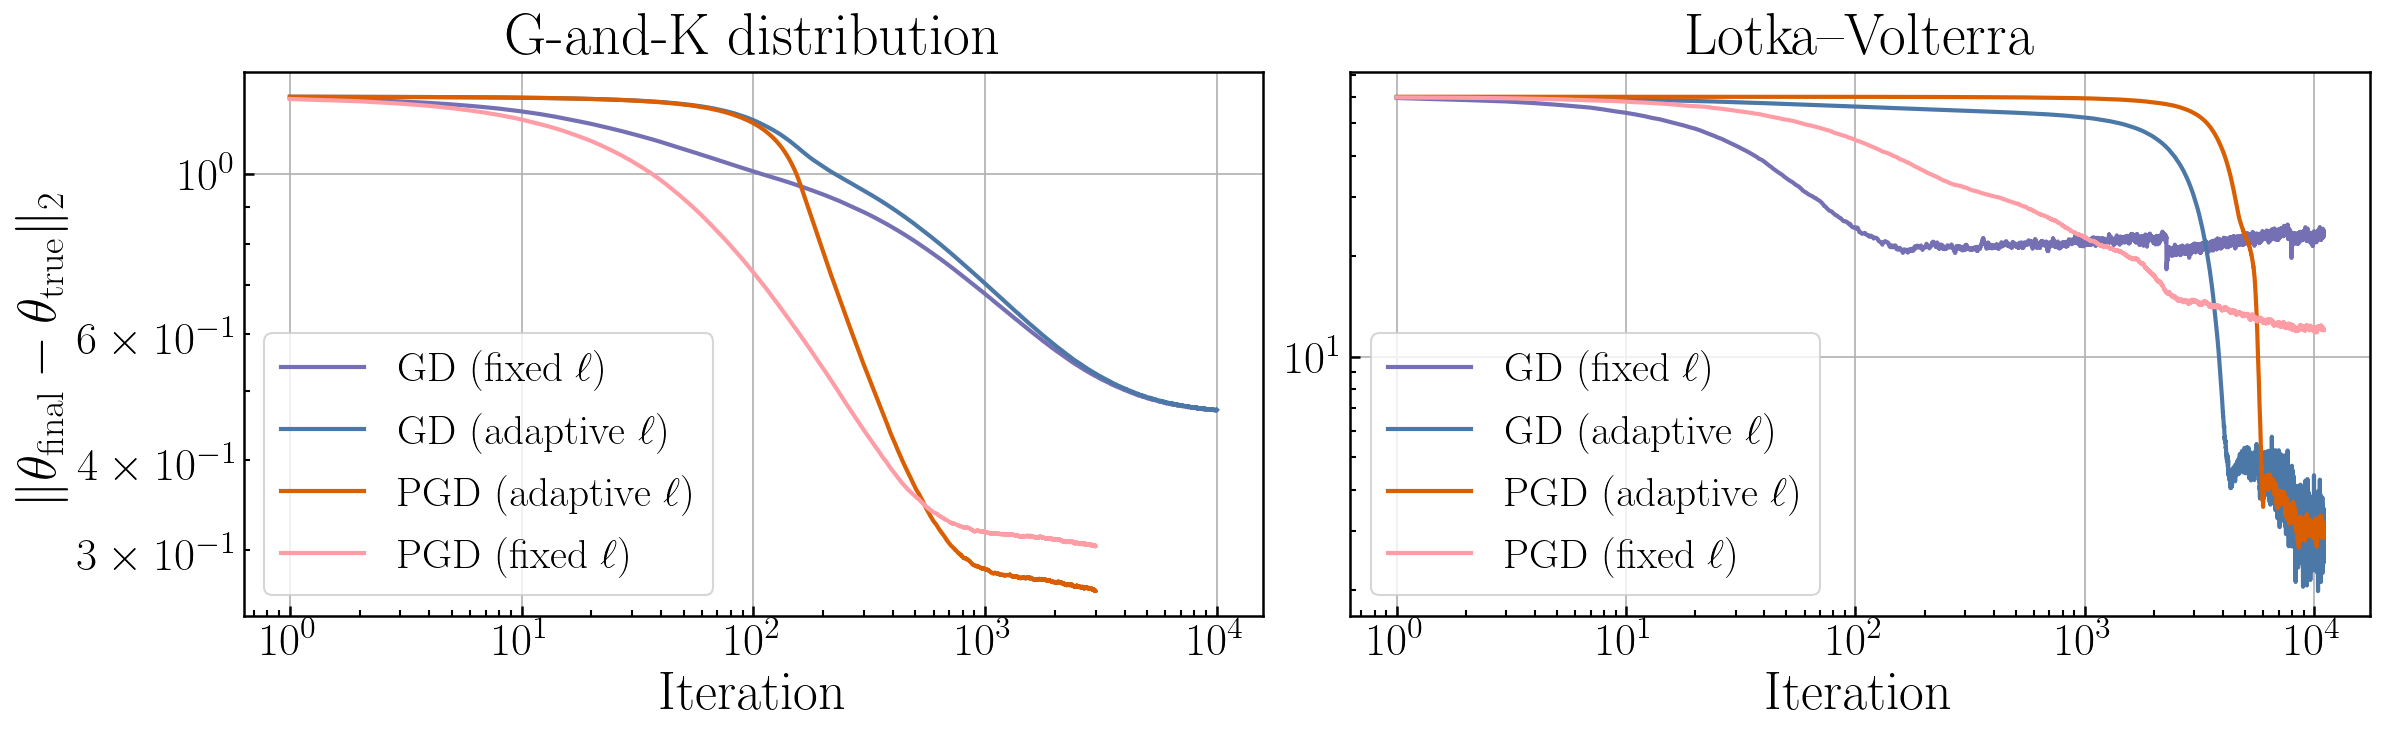

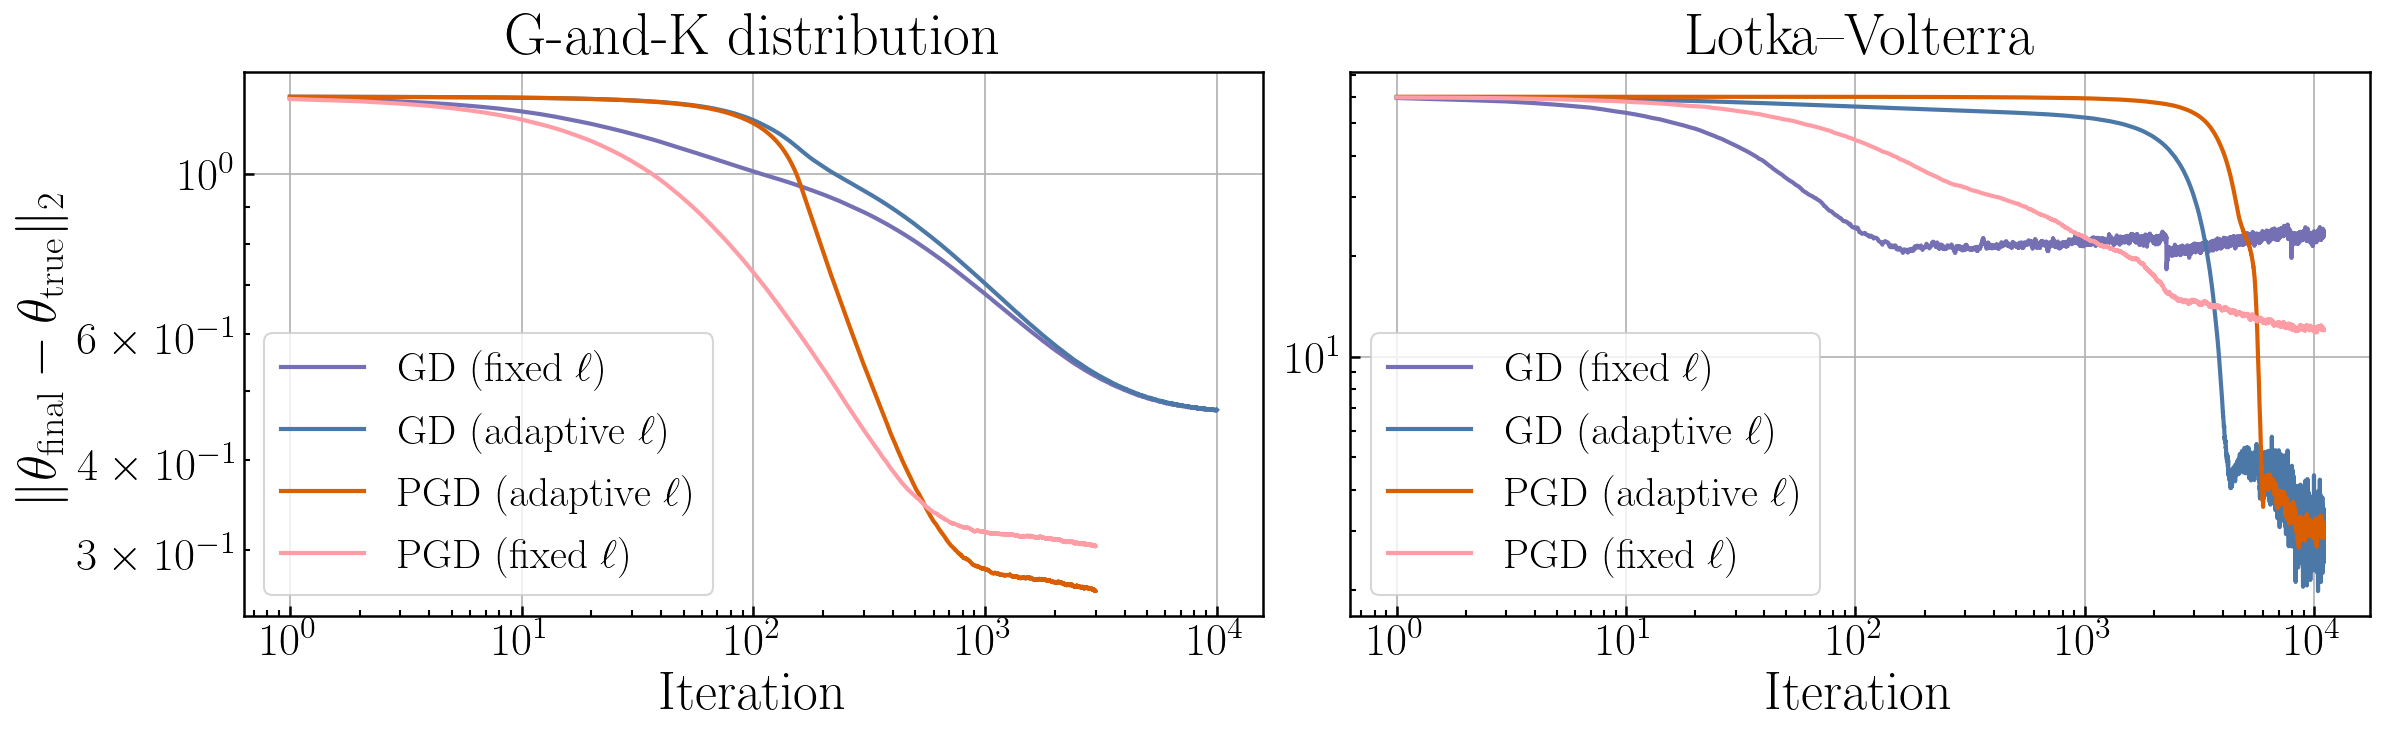

In [4]:
required_inputs = [gk_compare_npz, lv_compare_npz]
missing_inputs = [path for path in required_inputs if not path.exists()]

if not missing_inputs:
    try:
        fig = make_cross_method_summary(
            gk_compare_npz=gk_compare_npz,
            lv_compare_npz=lv_compare_npz,
            output_path=None,
            figsize=(16, 5),
            dpi=SUMMARY_DPI,
            max_iteration=11000,
        )
        fig.savefig(SUMMARY_OUTPUT, bbox_inches="tight")
        print(f"Saved figure to {SUMMARY_OUTPUT}")
        display(fig)
    except KeyError as exc:
        print(f"Figure not rendered because one or more required result keys are missing: {exc}")
else:
    print(
        f"Figure not rendered because {len(missing_inputs)} source input(s) are missing: "
        + ", ".join(str(path) for path in missing_inputs)
    )



In [5]:
# Combined summary figure rendered in the cell above.

